In [ ]:
# Google slides
# https://docs.google.com/presentation/d/1e7hblJVXniCWP5UqJ6MZdPmqU2kt7yi9MuJyDRjTCtU/edit?usp=sharing 

In [6]:
import matplotlib.pyplot as plt

# Set the font family to Arial
# https://g.co/gemini/share/3898a74b2d77
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial'] # Add Arial to the sans-serif list

plt.rcParams.update({
    'font.size': 20,
})

This notebook simulates the assignment of DNA methylation to paternal and maternal haplotypes in a population of $n$ cells. 
Given a cell, the probability that the paternal haplotype is methylated is $p$, and the probability that the maternal haplotype is methylated is $q$. 
Because each cell is an independent trial, the counts follow a Binomial distribution.

In [ ]:
import numpy as np

def simulate_methylation(n, p, q):
    """
    Simulates methylation for n cells.
    Returns the fraction of cells methylated on each haplotype, and their theoretical standard deviation.
    """
    # Sample the number of paternal haplotypes that are methylated.
    # Similar for maternal. 
    pat_meth_count = np.random.binomial(n, p)
    mat_meth_count = np.random.binomial(n, q)
    
    # Fractions
    pat_meth_frac_cells = pat_meth_count / n
    mat_meth_frac_cells = mat_meth_count / n
    
    # Theoretical Standard Deviation of fractions: sigma = sqrt(p(1-p)/n)
    sigma_pat_meth_frac_cells = np.sqrt(p * (1 - p) / n)
    sigma_mat_meth_frac_cells = np.sqrt(q * (1 - q) / n)
    
    return pat_meth_frac_cells, mat_meth_frac_cells, sigma_pat_meth_frac_cells, sigma_mat_meth_frac_cells

We will plot three categories of $(p, q)$ pairs:
1. **Independent**: Unrelated probabilities.
2. **Symmetric ($q = p$)**: Methylation is equally likely on both haplotypes.
3. **Complementary ($q = 1 - p$)**: Methylation on one haplotype is anti-correlated to methylation on the other.

**Error Bars:** The bars on each point represent $\pm 1$ theoretical standard deviation ($\sigma$).

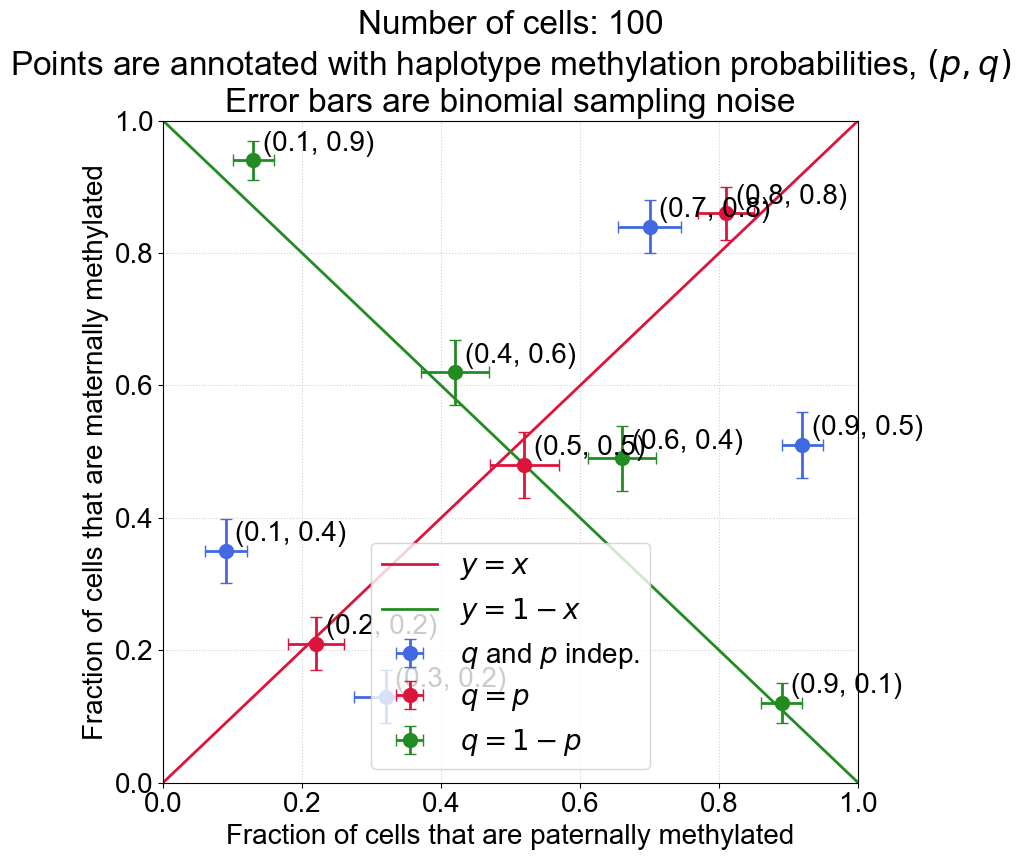

In [56]:
N = 100  # Number of cells 

# Define (p, q) pairs for different scenarios
data_groups = {
    "$q$ and $p$ indep.": ([(0.1, 0.4), (0.3, 0.2), (0.7, 0.8), (0.9, 0.5)], "royalblue", "o"),
    "$q = p$": ([(0.2, 0.2), (0.5, 0.5), (0.8, 0.8)], "crimson", "o"),
    "$q = 1 - p$": ([(0.1, 0.9), (0.4, 0.6), (0.6, 0.4), (0.9, 0.1)], "forestgreen", "o")
}

plt.figure(figsize=(9, 9))

for label, (pairs, color, marker) in data_groups.items():
    is_first = True
    for p, q in pairs:
        m_pat, m_mat, s_pat, s_mat = simulate_methylation(N, p, q)
        plt.errorbar(
            m_pat, m_mat, 
            xerr=s_pat, yerr=s_mat, 
            fmt=marker, color=color, ecolor=color, capsize=4, alpha=1, linewidth=2, markersize=10,
            label=label if is_first else ""
        )
        is_first = False
        plt.annotate(
            f"({p}, {q})", 
            (m_pat, m_mat), 
            xytext=(7, 7), textcoords="offset points", fontsize=20, fontweight='bold'
        )

# Theoretical Reference Lines
line_range = np.linspace(0, 1, 100)
plt.plot(line_range, line_range, color='crimson', linestyle='-', linewidth=2, alpha=1, label='$y=x$')
plt.plot(line_range, 1 - line_range, color='forestgreen', linestyle='-', linewidth=2, alpha=1, label='$y=1-x$')

plt.xlabel("Fraction of cells that are paternally methylated")
plt.ylabel("Fraction of cells that are maternally methylated")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.xlim(0, 1)
plt.ylim(0, 1)
title = f'Number of cells: {N}\n'
title += f'Points are annotated with haplotype methylation probabilities, $(p,q)$\n'
title += f'Error bars are binomial sampling noise'
plt.title(title)
plt.tight_layout()
plt.show()

The variance of a binomial proportion is maximized when $p=0.5$. 

As we can see from the error bars:
1. **Sampling Error**: The points do not fall exactly on the theoretical $(p,q)$ coordinates due to random sampling.
2. **Effect of $n$**: If we increase the number of cells ($n$), the error bars will shrink according to $1/\sqrt{n}$.
3. **Consistency**: The points should fall within $\sigma$ of $(p,q)$ roughly 68% of the time.